Проект для попытки реализовать расчёт метрик

На своих данных (двумерных для простоты)

В этом проекте, основанного на MetricsKANTest, должно быть реаплизовано автоматическое обучение сети ( 50 раз) с сохранением получившихся метрик в файл csv 

Метрики должны быть расчитаны на основе 10% данных которые никак не участвовали в обучении 

In [108]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split

In [109]:
input_path='file_for_input/all_hour/SBER_tradestats_test_hour.csv'
save_metrics_path = 'file_for_output/hour_metrics/KAN/SBER_metrics.csv'

In [110]:
# Функция для вычисления метрик
def calculate_metrics(Y10, kan_predictions,name):
    
    rmse_kan = root_mean_squared_error(Y10, kan_predictions)
    mae_kan = mean_absolute_error(Y10, kan_predictions)
    mape_kan = mean_absolute_percentage_error(Y10, kan_predictions)
    r2_kan = r2_score(Y10, kan_predictions)
    msle_kan = mean_squared_log_error(Y10, kan_predictions)
    
    return rmse_kan, mae_kan, mape_kan, r2_kan, msle_kan, name

# Функция для сохранения метрик в CSV файл
def save_metrics_to_csv(metrics, filename=save_metrics_path):
    # Проверяем, существует ли файл
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        df = pd.DataFrame(columns=['RMSE', 'MAE', 'MAPE', 'R2', 'MSLE', 'Name'])

    # Добавляем новые метрики в DataFrame
    new_row = pd.DataFrame([metrics], columns=['RMSE', 'MAE', 'MAPE', 'R2', 'MSLE', 'Name'])
    df = pd.concat([df, new_row], ignore_index=True)

    # Сохраняем DataFrame в CSV файл
    df.to_csv(filename, index=False)


In [111]:
from kan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [112]:

data = pd.read_csv(input_path)

# ['vol','val','trades','trades_b','trades_s', 'val_b','val_s','vol_b','vol_s','pr_open_hour','pr_high_hour','pr_low_hour','pr_close_hour'] <- полный список параметров

date_df= data['tradedate'] + '-' + data['tradetime_hour'].astype(str)
X = data[['pr_open_hour']] # Не добавлются сюда другие лейблы
Y= data ['pr_close_hour']
# Разделение данных на обучающую и тестовую выборки те самые 10%
X, X10, Y, Y10 = train_test_split(X, Y, test_size=0.1, shuffle=False)
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [113]:
import time
# neurons_number = [1,2,3,4,5,10,15,20,30,50,100,200] - 75,40,150
# grid = [3, 6 ,10,20,30,50] - 100
# steps [20, 30, 50] - 100

#Остановились на переборе нейронов для сетки 10

# Параметры сети
secid = 'SBER'
neurons_number = 50
grid = 3
num_param= len(X.columns)
steps = 50
name = secid+ '_kan_' + 'n'+str(neurons_number) + 'g'+str(grid)+'s'+ str(steps) +'np' + str(num_param)
rand_seed= int ( time.time() )
print ( 'rand_seed = ',rand_seed)
num_rep = 3
name

rand_seed =  1733948128


'SBER_kan_n50g3s50np1'

In [114]:
fitdate= date_df[:len(Y)] # Даты для 90% основных данных, которые пойдут на обучение
date10 = date_df[len(Y):] # Даты для выделенных 10% данных

In [115]:
# Убедитесь, что device определен (проверить код в этой ячейке)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=42, shuffle=False)
train_date= fitdate[:len(y_train)] # Даты соответствующие тренировочной выборке
test_date= fitdate[len(y_train):] # Даты соответствующие тестовой выборке ( 40% данных отправленных на обучение)


# Преобразование в тензоры PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Создание правильного датасета для KAN
dataset = {
    'train_input': X_train_tensor,
    'train_label': y_train_tensor,
    'test_input': X_test_tensor,
    'test_label': y_test_tensor
}

In [116]:
print("Размер обучающей выборки (X_train):", X_train.shape)
print("Размер тестовой выборки (X_test):", X_test.shape)
print("Размер меток обучающей выборки (y_train):", y_train.shape)
print("Размер меток тестовой выборки (y_test):", y_test.shape)

Размер обучающей выборки (X_train): (6521, 1)
Размер тестовой выборки (X_test): (1151, 1)
Размер меток обучающей выборки (y_train): (6521,)
Размер меток тестовой выборки (y_test): (1151,)


In [117]:
dataset['train_input'].shape, dataset['train_label'].shape 

(torch.Size([6521, 1]), torch.Size([6521, 1]))

In [118]:
# Создание модели KAN с измененными параметрами
model = KAN(width=[1, neurons_number, 1], grid=grid, k=3, seed = rand_seed)# убрал seed=0

# Обучение модели
#results = model2.train(dataset, opt="LBFGS", steps=20, lamb=0.01, lamb_entropy=10)
results = model.fit(dataset, opt="LBFGS", steps=steps)
# Вывод результатов
train_loss = results['train_loss'][-1]  # последнее значение обучающей ошибки
test_loss = results['test_loss'][-1]  # последнее значение ошибки на тесте
print(f'Train loss: {train_loss}, Test loss: {test_loss}')


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.78e+00 | test_loss: 8.68e-01 | reg: 4.84e+01 | : 100%|█| 50/50 [00:47<00:00,  1.06it

saving model version 0.1
Train loss: 1.7806434631347656, Test loss: 0.8676432967185974


10 % Были выделены И ИСПОЛЬЗОВАНЫ  

In [119]:

# Для KAN
X_test_tensor = torch.tensor(X10.values, dtype=torch.float32)  # Преобразование в тензор, если еще не сделано
kan_predictions = model(X_test_tensor).detach().numpy()  # Получение предсказаний и преобразование их в NumPy массив

In [120]:
from sklearn.metrics import *



# Оценка для KAN
rmse_kan = root_mean_squared_error(Y10, kan_predictions)
mae_kan = mean_absolute_error(Y10, kan_predictions)
mape_kan = mean_absolute_percentage_error(Y10, kan_predictions)
r2_kan = r2_score(Y10, kan_predictions)
msle_kan = mean_squared_log_error(Y10, kan_predictions)


# mse_kan = mean_squared_error(y_test, kan_predictions)
# mae_kan = mean_absolute_error(y_test, kan_predictions)
# r2_kan = r2_score(y_test, kan_predictions)


print("KAN - RMSE:", rmse_kan, "MAE:", mae_kan,"MAPE:", mape_kan, "R^2:", r2_kan,"MSLE:", msle_kan)


KAN - RMSE: 0.8571954179141081 MAE: 0.5954837046865838 MAPE: 0.002305089934029207 R^2: 0.9924857705971207 MSLE: 1.0815082075899178e-05


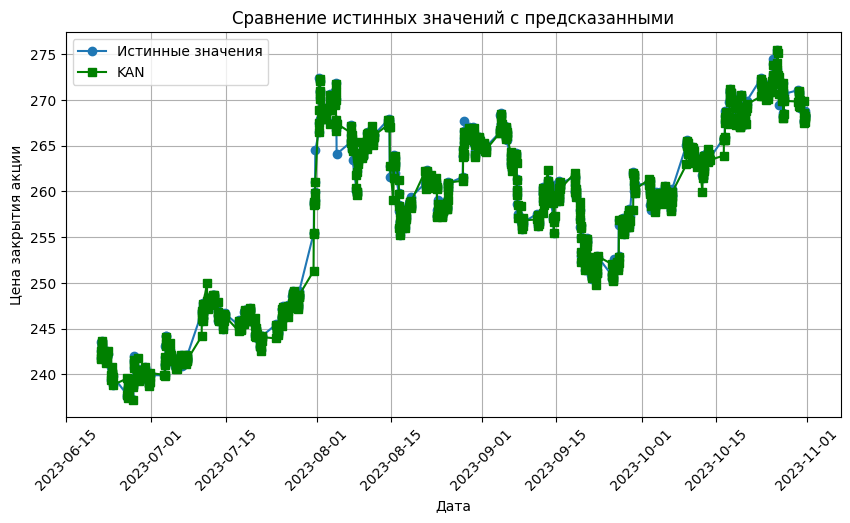

In [121]:
import matplotlib.pyplot as plt

date10 = pd.to_datetime(date10)
# Создание графика
plt.figure(figsize=(10, 5))
plt.plot(date10, Y10.reset_index(drop=True), label='Истинные значения', marker='o')
plt.plot(date10, kan_predictions, 'g', label='KAN', marker='s')
plt.title('Сравнение истинных значений с предсказанными')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия акции')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Поворот меток дат для лучшей читаемости



# Сохранение графика в нужную директорию
plt.savefig('file_for_output/hour_metrics/KAN/graphics/'+name+'graph_full.png', bbox_inches='tight')
plt.show()



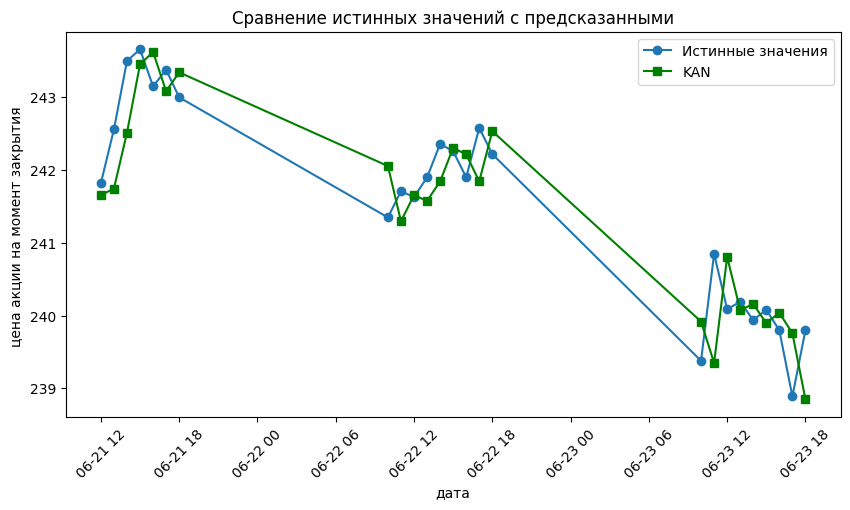

In [122]:
import matplotlib.pyplot as plt
n = 25 # До кого значения рассматривать график

plt.figure(figsize=(10, 5))
plt.plot(date10[:n],Y10.reset_index(drop=True)[:n], label='Истинные значения', marker='o')
plt.plot(date10[:n],kan_predictions[:n], 'g', label='KAN', marker='s')
plt.title('Сравнение истинных значений с предсказанными')
plt.xlabel('дата')
plt.ylabel('цена акции на момент закрытия ')
plt.xticks(rotation=45)  # Поворот меток дат для лучшей читаемост
plt.legend()


# Сохранение графика в нужную директорию
plt.savefig('file_for_output/hour_metrics/KAN/graphics/'+name+'graph_part.png', bbox_inches='tight')

plt.show()


In [123]:

for i in range(num_rep):  # Пример цикла
    rand_seed= int ( time.time() )
    print ( 'rand_seed = ', rand_seed)
    # Создание модели KAN с измененными параметрами
    model = KAN(width=[1, neurons_number, 1], grid=grid, k=3, seed = rand_seed ) # убрал seed=0

    # Обучение модели
    #results = model2.train(dataset, opt="LBFGS", steps=20, lamb=0.01, lamb_entropy=10)
    results = model.fit(dataset, opt="LBFGS", steps=steps)
    # Вывод результатов
    train_loss = results['train_loss'][-1]  # последнее значение обучающей ошибки
    test_loss = results['test_loss'][-1]  # последнее значение ошибки на тесте
    print(f'Train loss: {train_loss}, Test loss: {test_loss}')
    
    # Для KAN
    X_test_tensor = torch.tensor(X10.values, dtype=torch.float32)  # Преобразование в тензор, если еще не сделано
    kan_predictions = model(X_test_tensor).detach().numpy()  # Получение предсказаний и преобразование их в NumPy массив
    
    
    metrics = calculate_metrics(Y10, kan_predictions, name)
    save_metrics_to_csv(metrics)

rand_seed =  1733948176
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.78e+00 | test_loss: 8.69e-01 | reg: 4.90e+01 | : 100%|█| 50/50 [00:40<00:00,  1.24it


saving model version 0.1
Train loss: 1.7806061506271362, Test loss: 0.8694466352462769
rand_seed =  1733948217
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e+00 | test_loss: 8.56e-01 | reg: 4.89e+01 | : 100%|█| 50/50 [00:29<00:00,  1.70it


saving model version 0.1
Train loss: 1.785259485244751, Test loss: 0.8555728793144226
rand_seed =  1733948246
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.78e+00 | test_loss: 8.83e-01 | reg: 4.29e+01 | : 100%|█| 50/50 [00:54<00:00,  1.09s/

saving model version 0.1
Train loss: 1.7794995307922363, Test loss: 0.8831979632377625
